In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

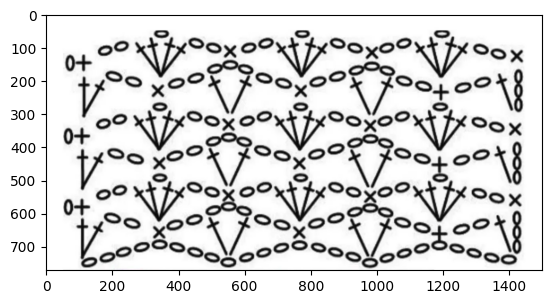

In [9]:
img = cv.imread("data/raw/easy/4.png")
plt.imshow(img)

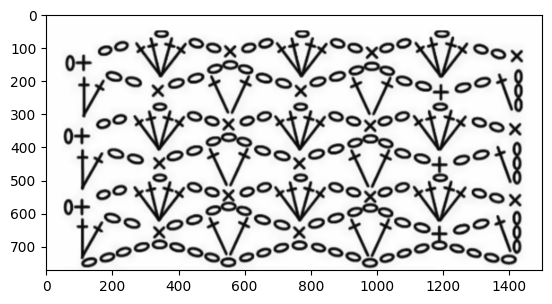

In [10]:
# Denoise
img_denoised = cv.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)
plt.imshow(img_denoised)

In [11]:
import cv2 as cv
import numpy as np

def detect_symbols(scene_gray, templates, threshold=0.8):
    all_boxes = []
    all_labels = []

    for label, temp_img in templates.items():
        w, h = temp_img.shape[::-1]
        res = cv.matchTemplate(scene_gray, temp_img, cv.TM_CCOEFF_NORMED)
        
        loc = np.where(res >= threshold)
        for pt in zip(*loc[::-1]):
            # Use only numbers for the boxes array
            all_boxes.append([pt[0], pt[1], pt[0] + w, pt[1] + h, res[pt[1], pt[0]]])
            all_labels.append(label)

    if len(all_boxes) == 0:
        return []

    # Convert to float array for math
    boxes_np = np.array(all_boxes, dtype="float")
    
    # Run NMS and get the indices of the boxes we want to keep
    pick_indices = nms(boxes_np)
    
    # Return the boxes AND their corresponding labels
    final_results = []
    for i in pick_indices:
        final_results.append({
            "box": boxes_np[i],
            "label": all_labels[i]
        })
        
    return final_results

def nms(boxes, overlapThresh=0.3):
    if len(boxes) == 0: return []
    
    pick = []
    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,2]
    y2 = boxes[:,3]
    scores = boxes[:,4]
    
    area = (x2 - x1 + 1) * (y2 - y1 + 1)
    idxs = np.argsort(scores)

    while len(idxs) > 0:
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)
        
        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.minimum(x2[i], x2[idxs[:last]])
        yy2 = np.minimum(y2[i], y2[idxs[:last]])
        
        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)
        
        overlap = (w * h) / area[idxs[:last]]
        
        idxs = np.delete(idxs, np.concatenate(([last], np.where(overlap > overlapThresh)[0])))

    return pick # Returns indices

# --- SETUP ---
# 1. Load your 10 symbols as a dictionary of grayscale templates
templates = { "o": cv.imread('data/raw/templates/t_o.png', 0), "x": cv.imread('data/raw/templates/t_x.png', 0) }

# 2. Run Detection
img = cv.imread("data/raw/easy/4.png", 0)
results = detect_symbols(img, templates)

for res in results:
    b = res['box'].astype(int)
    label = res['label']
    # Draw the rectangle
    cv.rectangle(img, (b[0], b[1]), (b[2], b[3]), (0, 255, 0), 2)
    cv.putText(img, label, (b[0], b[1]-10), cv.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

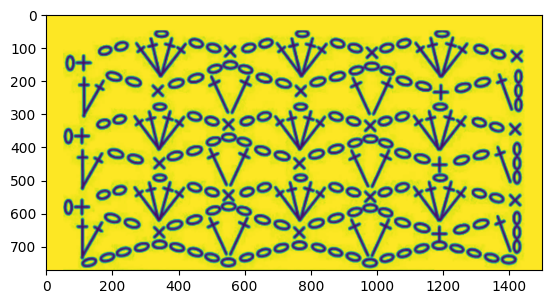

In [12]:
plt.imshow(img)